# InstantX IP-Adapter recovery test

Sanity-ceiling for the new pretrained-adapter pipeline. Feeds the pipeline the **perfect** init latent (VAE-encoded ground-truth stimulus) and the **perfect** SigLIP embedding (ground-truth cache entry), then asks: given a partially-noised version of the init latent, can the adapter-conditioned denoise recover the original?

This is the upper bound. If recovery fails here, nothing with neural-decoded inputs will work downstream. If it succeeds, we know the adapter + init-latent + aperture-compositing path is wired correctly, and any downstream failure lives in the neural decoder, not the generator.

What we sweep:
- `strength` ∈ {0.3, 0.5, 0.7, 0.9} — how much noise is added to the init latent before denoising starts.
- `ip_adapter_scale` ∈ {0.0, 0.5, 1.0} — 0.0 isolates the "unconditional VAE roundtrip + scheduler" path so we can see how much of the recovery is the adapter vs just the init latent bleeding through.
- `aperture_composite` ∈ {True, False} — on/off so we can see the adapter's contribution inside the trained ring separately from the hard-paste of the untrained ring.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
from PIL import Image

from config_const import SIGLIP_EMBEDDINGS_PATH, RUST_STIM_DIR, N_STIMULI
from generation.flux_instantx import (
    load_pipeline,
    generate_img2img,
    encode_image,
    decode_latent,
)

In [2]:
pipe, image_proj = None, None
torch.cuda.empty_cache()
pipe, image_proj = load_pipeline(device="cuda", default_scale=1.0)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [3]:
# Ground-truth SigLIP cache (300, 1152)
all_embeds = torch.load(SIGLIP_EMBEDDINGS_PATH, weights_only=True)
print(f"SigLIP cache: {tuple(all_embeds.shape)}")

# Pick a handful of stimuli to test
STIM_INDICES = [0, 7, 42, 123]
IMAGE_SIZE = 512

def load_stim(idx: int) -> Image.Image:
    return Image.open(RUST_STIM_DIR / f"{idx:04d}.png").convert("RGB")

stim_pils = [load_stim(i) for i in STIM_INDICES]
stim_embs = [all_embeds[i] for i in STIM_INDICES]
for idx, pil in zip(STIM_INDICES, stim_pils):
    print(f"  stim {idx}: {pil.size}")

SigLIP cache: (300, 1152)
  stim 0: (276, 276)
  stim 7: (276, 276)
  stim 42: (276, 276)
  stim 123: (276, 276)


## VAE round-trip sanity check

Before running the adapter at all, confirm the grayscale-luminance VAE encode/decode is lossless enough that any recovery failure later is due to the adapter or noising, not the VAE itself.

In [5]:
def vae_roundtrip(pil: Image.Image) -> Image.Image:
    init = pil.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
    latent = encode_image(pipe, init)
    return decode_latent(pipe, latent)

for idx, pil in zip(STIM_INDICES, stim_pils):
    rt = vae_roundtrip(pil)
    a = np.array(pil.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)).astype(float)
    # luminance-only compare since encode_image grayscales the input
    a_gray = 0.2989*a[...,0] + 0.5870*a[...,1] + 0.1140*a[...,2]
    b_gray = np.array(rt.convert("L")).astype(float)
    mse = ((a_gray - b_gray) ** 2).mean()
    print(f"stim {idx}: VAE roundtrip grayscale MSE = {mse:.2f}")

stim 0: VAE roundtrip grayscale MSE = 2.30
stim 7: VAE roundtrip grayscale MSE = 2.48
stim 42: VAE roundtrip grayscale MSE = 2.13
stim 123: VAE roundtrip grayscale MSE = 2.54


## Recovery sweep

For one stimulus, sweep (strength × ip_adapter_scale) with aperture compositing **on**. Each cell output is a grid of `(original | recovered)` pairs.

In [4]:
def make_grid(pairs: list[tuple[Image.Image, Image.Image]], label: str, size: int = 256) -> Image.Image:
    """Side-by-side (original | recovered) row with a label strip."""
    from PIL import ImageDraw
    n = len(pairs)
    label_h = 24
    grid = Image.new("RGB", (size * 2 * n, size + label_h), (30, 30, 30))
    draw = ImageDraw.Draw(grid)
    draw.text((8, 4), label, fill=(230, 230, 230))
    for i, (orig, rec) in enumerate(pairs):
        grid.paste(orig.resize((size, size)), (i * size * 2, label_h))
        grid.paste(rec.resize((size, size)),  (i * size * 2 + size, label_h))
    return grid

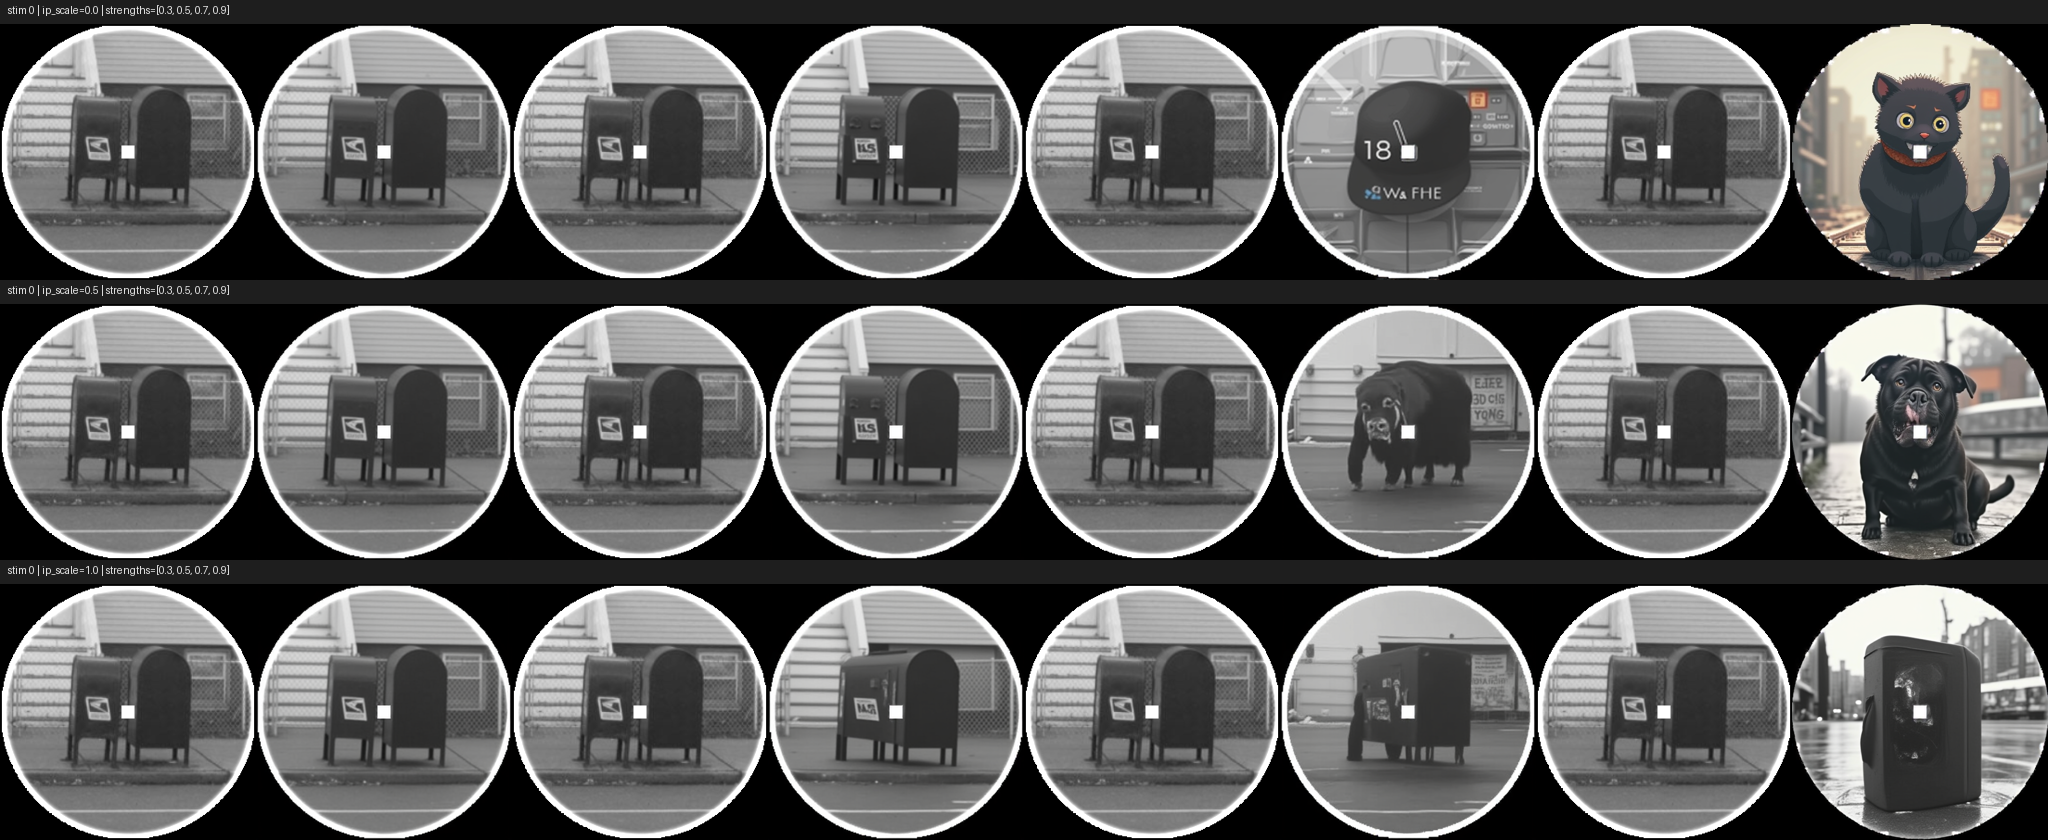

In [6]:
TEST_IDX = 0
init_pil = stim_pils[0]
init_emb = stim_embs[0]

STRENGTHS = [0.3, 0.5, 0.7, 0.9]
IP_SCALES = [0.0, 0.5, 1.0]
NUM_STEPS = 20
SEED = 0

grids = []
for ip_scale in IP_SCALES:
    pairs = []
    for strength in STRENGTHS:
        rec = generate_img2img(
            pipe, image_proj, init_pil, init_emb,
            strength=strength,
            height=IMAGE_SIZE, width=IMAGE_SIZE,
            num_inference_steps=NUM_STEPS,
            guidance_scale=3.5,
            ip_adapter_scale=ip_scale,
            seed=SEED,
            aperture_composite=True,
            show_progress=False,
        )
        pairs.append((init_pil, rec))
    label = f"stim {TEST_IDX} | ip_scale={ip_scale:.1f} | strengths={STRENGTHS}"
    grids.append(make_grid(pairs, label))

full = Image.new("RGB", (grids[0].width, sum(g.height for g in grids)), (20, 20, 20))
y = 0
for g in grids:
    full.paste(g, (0, y))
    y += g.height
full

## Aperture compositing: on vs off

Fix `strength=0.7`, `ip_scale=1.0`. Compare with and without per-step aperture compositing. "off" should let the adapter repaint everywhere including the untrained ring; "on" should keep the untrained ring pinned to the original.

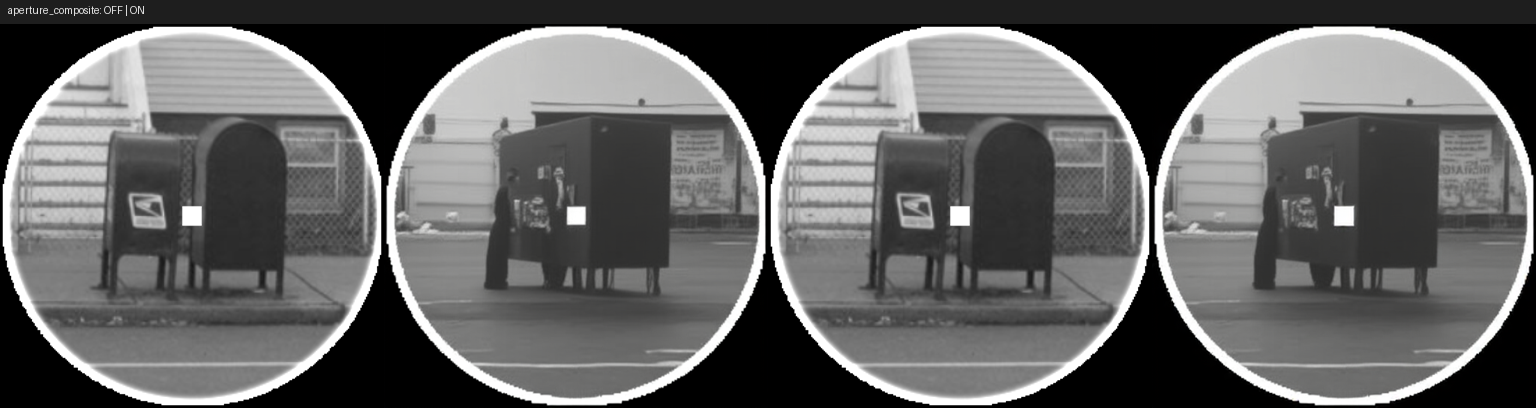

In [7]:
ap_pairs = []
for composite in [False, True]:
    rec = generate_img2img(
        pipe, image_proj, init_pil, init_emb,
        strength=0.7,
        height=IMAGE_SIZE, width=IMAGE_SIZE,
        num_inference_steps=NUM_STEPS,
        guidance_scale=3.5,
        ip_adapter_scale=1.0,
        seed=SEED,
        aperture_composite=composite,
        show_progress=False,
    )
    ap_pairs.append((init_pil, rec))

make_grid(ap_pairs, "aperture_composite: OFF | ON", size=384)

## Multi-stimulus spot check

Fixed settings, multiple stimuli. This is the test to look at when deciding whether the upper-bound recovery is acceptable across the dataset, not just one lucky image.

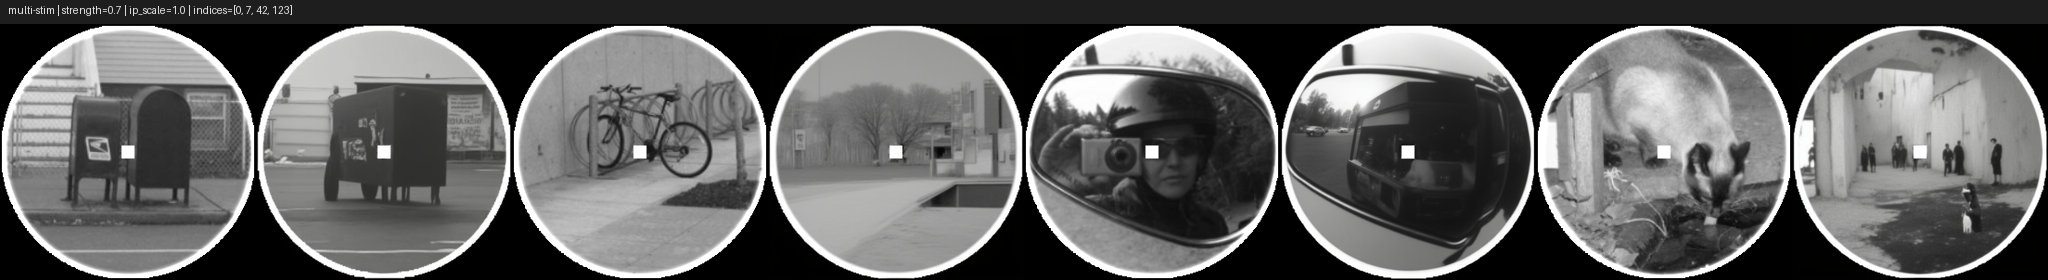

In [8]:
multi_pairs = []
for idx, pil, emb in zip(STIM_INDICES, stim_pils, stim_embs):
    rec = generate_img2img(
        pipe, image_proj, pil, emb,
        strength=0.7,
        height=IMAGE_SIZE, width=IMAGE_SIZE,
        num_inference_steps=NUM_STEPS,
        guidance_scale=3.5,
        ip_adapter_scale=1.0,
        seed=int(idx),
        aperture_composite=True,
        show_progress=False,
    )
    multi_pairs.append((pil, rec))

make_grid(multi_pairs, f"multi-stim | strength=0.7 | ip_scale=1.0 | indices={STIM_INDICES}", size=256)

## Quantitative recovery metric

Luminance MSE inside the trained aperture between the original stimulus and the recovery. Lower is better. We report it at each (strength × ip_scale) combo so we can see where the adapter actually helps vs hurts relative to the init-latent bleed-through.

In [8]:
from generation.aperture import load_packed_aperture_mask

def aperture_pixel_mask(image_size: int) -> np.ndarray:
    """Binary (H, W) mask: 1 inside trained aperture, 0 outside / on fixation."""
    yy, xx = np.meshgrid(np.arange(image_size), np.arange(image_size), indexing="ij")
    c = (image_size - 1) / 2
    r = image_size / 2
    circle = ((yy - c) ** 2 + (xx - c) ** 2) <= r ** 2
    half = int(round(image_size * 0.06 / 2))
    center_sq = np.zeros_like(circle, dtype=bool)
    lo = int(round(c)) - half
    hi = int(round(c)) + half + 1
    center_sq[lo:hi, lo:hi] = True
    return (circle & ~center_sq).astype(np.float32)

pixel_mask = aperture_pixel_mask(IMAGE_SIZE)
mask_sum = pixel_mask.sum()

def masked_lum_mse(orig: Image.Image, rec: Image.Image) -> float:
    a = np.array(orig.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)).astype(np.float32)
    a = 0.2989*a[...,0] + 0.5870*a[...,1] + 0.1140*a[...,2]
    b = np.array(rec.convert("L")).astype(np.float32)
    err = ((a - b) ** 2) * pixel_mask
    return float(err.sum() / mask_sum)

print(f"{'strength':>10} {'ip_scale':>10} {'MSE':>10}")
for strength in STRENGTHS:
    for ip_scale in IP_SCALES:
        rec = generate_img2img(
            pipe, image_proj, init_pil, init_emb,
            strength=strength,
            height=IMAGE_SIZE, width=IMAGE_SIZE,
            num_inference_steps=NUM_STEPS,
            guidance_scale=3.5,
            ip_adapter_scale=ip_scale,
            seed=SEED,
            aperture_composite=True,
            show_progress=False,
        )
        mse = masked_lum_mse(init_pil, rec)
        print(f"{strength:>10.2f} {ip_scale:>10.2f} {mse:>10.2f}")

  strength   ip_scale        MSE


NameError: name 'STRENGTHS' is not defined

## Text prompt contribution

The IP-Adapter is weak for out-of-distribution grayscale stimuli. The FLUX text encoder is a separate, independently strong conditioning path. We test whether adding the ground-truth BLIP2 caption as `prompt` recovers semantic content the adapter alone misses.

Three conditions, fixed `strength=0.7`, `ip_scale=1.0`:

- **no text** — empty prompt (current default)
- **text only** — BLIP2 caption, `ip_scale=0.0` (text encoder alone, no adapter)
- **text + adapter** — BLIP2 caption, `ip_scale=1.0` (both paths active)

In [ ]:
import json
from config_const import BLIP2_CAPTIONS_PATH, CLIP_EMBEDS_PATH, T5_EMBEDS_PATH
from generation.flux_instantx import encode_text_embeds

with open(BLIP2_CAPTIONS_PATH) as f:
    captions = json.load(f)

# Compute and cache CLIP + T5 embeddings for all 300 stimuli if not already done.
if CLIP_EMBEDS_PATH.exists() and T5_EMBEDS_PATH.exists():
    clip_embeds_all = torch.load(CLIP_EMBEDS_PATH, weights_only=True)
    t5_embeds_all   = torch.load(T5_EMBEDS_PATH,   weights_only=True)
    print(f"Loaded from cache: CLIP {tuple(clip_embeds_all.shape)}, T5 {tuple(t5_embeds_all.shape)}")
else:
    all_prompts = [captions[str(i)] for i in range(len(captions))]
    clip_embeds_all, t5_embeds_all = encode_text_embeds(pipe, all_prompts)
    CLIP_EMBEDS_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(clip_embeds_all, CLIP_EMBEDS_PATH)
    torch.save(t5_embeds_all,   T5_EMBEDS_PATH)
    print(f"Saved: CLIP {tuple(clip_embeds_all.shape)}, T5 {tuple(t5_embeds_all.shape)}")

# Slice out the four test stimuli.
stim_clip = [clip_embeds_all[i].unsqueeze(0) for i in STIM_INDICES]  # list of (1, 768)
stim_t5   = [t5_embeds_all[i].unsqueeze(0)   for i in STIM_INDICES]  # list of (1, 512, 4096)
for idx, c, t in zip(STIM_INDICES, stim_clip, stim_t5):
    print(f"  stim {idx}: CLIP {tuple(c.shape)}  T5 {tuple(t.shape)}  prompt={captions[str(idx)]!r}")


Loaded from cache: CLIP (300, 768), T5 (300, 512, 4096)
  stim 0: CLIP (1, 768)  T5 (1, 512, 4096)  prompt='a grayscale photograph of a mailbox on the side walk'
  stim 7: CLIP (1, 768)  T5 (1, 512, 4096)  prompt='a grayscale photograph of a bicycle parked on the sidewalk'
  stim 42: CLIP (1, 768)  T5 (1, 512, 4096)  prompt='a grayscale photograph of a person taking their own picture'
  stim 123: CLIP (1, 768)  T5 (1, 512, 4096)  prompt='a grayscale photograph of a cat drinking from the water'


       condition   stim        MSE
         no text      0     270.04
         no text      7     246.01
         no text     42     336.27
         no text    123     443.46
       text only      0     315.74
       text only      7     312.36
       text only     42     389.86
       text only    123     525.32
  text + adapter      0     277.54
  text + adapter      7     250.58
  text + adapter     42     338.13
  text + adapter    123     449.69


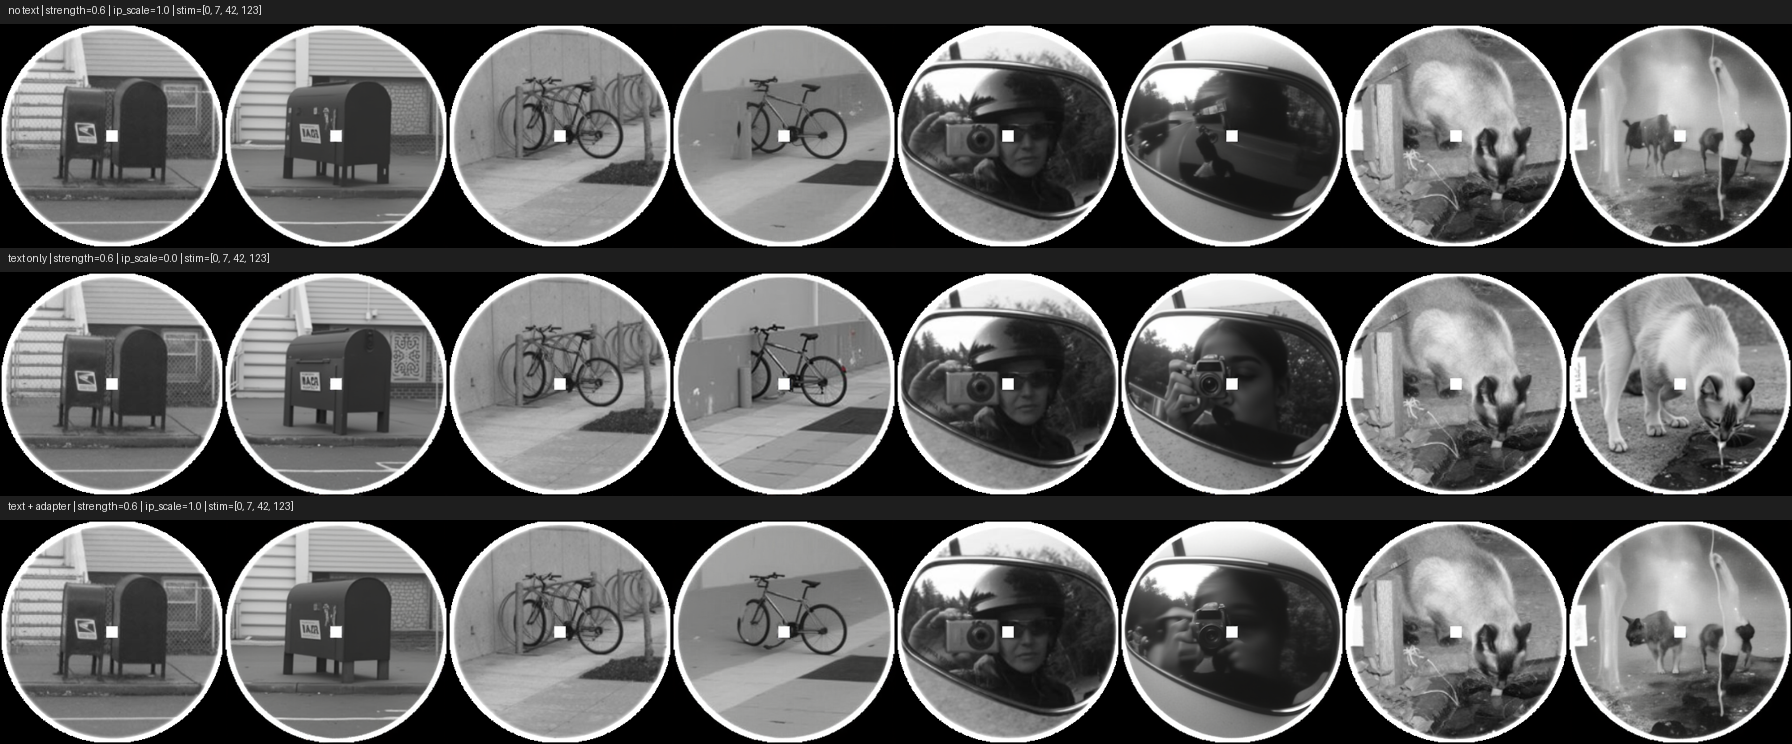

In [12]:
TEXT_STRENGTH = 0.6
TEXT_STEPS = 20
TEXT_SEED = 0

# (cond_name, use_text_embeds, ip_scale)
conditions = [
    ("no text",        False, 1.0),
    ("text only",      True,  0.0),
    ("text + adapter", True,  1.0),
]

text_grids = []
print(f"{'condition':>16} {'stim':>6} {'MSE':>10}")
for cond_name, use_text, ip_scale in conditions:
    pairs = []
    for idx, pil, emb, clip_e, t5_e in zip(STIM_INDICES, stim_pils, stim_embs, stim_clip, stim_t5):
        rec = generate_img2img(
            pipe, image_proj, pil, emb,
            strength=TEXT_STRENGTH,
            height=IMAGE_SIZE, width=IMAGE_SIZE,
            num_inference_steps=TEXT_STEPS,
            guidance_scale=3.5,
            ip_adapter_scale=ip_scale,
            prompt_embeds=t5_e if use_text else None,
            pooled_prompt_embeds=clip_e if use_text else None,
            seed=TEXT_SEED,
            aperture_composite=True,
            show_progress=False,
        )
        mse = masked_lum_mse(pil, rec)
        print(f"{cond_name:>16} {idx:>6} {mse:>10.2f}")
        pairs.append((pil, rec))
    label = f"{cond_name} | strength={TEXT_STRENGTH} | ip_scale={ip_scale} | stim={STIM_INDICES}"
    text_grids.append(make_grid(pairs, label, size=224))

full_text = Image.new("RGB", (text_grids[0].width, sum(g.height for g in text_grids)), (20, 20, 20))
y = 0
for g in text_grids:
    full_text.paste(g, (0, y))
    y += g.height
full_text


## What to look for

- **VAE roundtrip MSE**: should be small (tens of units on a 0–255 scale). If this is huge, the grayscale-luminance encoding is broken.
- **Recovery sweep**: at low strength (0.3) recovery should be near-perfect regardless of `ip_scale` because the init latent dominates. At high strength (0.9) the init is almost pure noise, so recovery depends heavily on `ip_scale` — this is where the adapter's contribution becomes visible.
- **ip_scale=0 vs ip_scale=1** at `strength=0.7`: the difference between these is exactly what the InstantX adapter is doing. If they look identical, the adapter isn't being applied (check `set_ip_adapter_scale`).
- **Aperture OFF vs ON**: with OFF, the untrained ring should drift with the adapter; with ON it should match the original. If ON doesn't match the original outside the ring, the compositing is broken.
- **Masked MSE table**: at `ip_scale=1.0`, MSE should be non-increasing as strength decreases. The adapter should reduce MSE compared to `ip_scale=0.0` at the same strength — if it doesn't, the adapter is adding noise rather than information.